In [ ]:
pip install kagglehub

In [ ]:
import kagglehub

path = kagglehub.dataset_download("dmitrybabko/speech-emotion-recognition-en")

print("Path to dataset files:", path)

100%|██████████| 987M/987M [00:19<00:00, 54.3MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/dmitrybabko/speech-emotion-recognition-en/versions/1


Using Ravdess Dataset

In [ ]:
import os
import librosa
import numpy as np
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

def load_data(dataset_path):
    emotions = {"01": "neutral", "02": "calm", "03": "happy", "04": "sad",
                "05": "angry", "06": "fearful", "07": "disgust", "08": "surprised"}
    data = []
    labels = []

    ravdess_path = os.path.join(dataset_path, 'Ravdess', 'audio_speech_actors_01-24')

    for subdir, dirs, files in os.walk(ravdess_path):
        for file in files:
            if file.endswith(".wav"):
                emotion = emotions[file.split("-")[2]]
                labels.append(emotion)

                filepath = os.path.join(subdir, file)
                signal, sr = librosa.load(filepath, sr=22050)

                mfcc = librosa.feature.mfcc(y=signal, sr=sr, n_mfcc=40)
                mfcc_scaled = np.mean(mfcc.T, axis=0)
                data.append(mfcc_scaled)

    return np.array(data), np.array(labels)

dataset_path = "/root/.cache/kagglehub/datasets/dmitrybabko/speech-emotion-recognition-en/versions/1"
data, labels = load_data(dataset_path)

if data.shape[0] == 0:
    print("No data loaded. Please check the dataset and path.")
else:
    print(f"Data loaded: {data.shape[0]} samples")

    label_map = {label: idx for idx, label in enumerate(np.unique(labels))}
    labels_encoded = np.array([label_map[label] for label in labels])

    X_train, X_test, y_train, y_test = train_test_split(data, labels_encoded, test_size=0.2, random_state=42)

    y_train = to_categorical(y_train)
    y_test = to_categorical(y_test)

    num_classes = len(label_map)

    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import Dense, Dropout, LSTM

    model = Sequential([
        LSTM(256, activation='relu', input_shape=(X_train.shape[1], 1), return_sequences=True),
        Dropout(0.3),
        LSTM(128, activation='relu'),
        Dropout(0.3),
        Dense(64, activation='relu'),
        Dropout(0.3),
        Dense(num_classes, activation='softmax')
    ])

    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    model.summary()

    history = model.fit(X_train, y_train, epochs=50, batch_size=32, validation_data=(X_test, y_test))

    test_loss, test_acc = model.evaluate(X_test, y_test)
    print(f"Test Accuracy: {test_acc:.2f}")


Data loaded: 1440 samples


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                        │ (None, 40, 256)             │         264,192 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_5 (Dropout)                  │ (None, 40, 256)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_2 (LSTM)                        │ (None, 128)                 │         197,120 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_6 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_7 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 8)                   │             520 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 470,088 (1.79 MB)

 Trainable params: 470,088 (1.79 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 12s 204ms/step - accuracy: 0.1251 - loss: 721.6725 - val_accuracy: 0.1076 - val_loss: 10295.4570
Epoch 2/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 9s 254ms/step - accuracy: 0.1287 - loss: 46155.9258 - val_accuracy: 0.1493 - val_loss: 106943.2344
Epoch 3/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 8s 194ms/step - accuracy: 0.1229 - loss: 165251.3438 - val_accuracy: 0.0660 - val_loss: 86470.3672
Epoch 4/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 10s 193ms/step - accuracy: 0.1609 - loss: 139433.7188 - val_accuracy: 0.1146 - val_loss: 58849.5469
Epoch 5/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 11s 219ms/step - accuracy: 0.1156 - loss: 82817.8828 - val_accuracy: 0.1076 - val_loss: 20881.3594
Epoch 6/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 11s 249ms/step - accuracy: 0.1323 - loss: 41541.2578 - val_accuracy: 0.1493 - val_loss: 2.0725
Epoch 7/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 9s 217ms/step - accuracy: 0.1327 - loss: 18254.3340 - val_accuracy: 0.1493 - val_loss: 4435.2173
Epoch 8/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 8s 225ms/s

Using Crema Dataset

Data loaded: 7442 samples


/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
187/187 ━━━━━━━━━━━━━━━━━━━━ 28s 138ms/step - accuracy: 0.2025 - loss: 1.7769 - val_accuracy: 0.2693 - val_loss: 1.6671
Epoch 2/50
187/187 ━━━━━━━━━━━━━━━━━━━━ 41s 140ms/step - accuracy: 0.2934 - loss: 1.6465 - val_accuracy: 0.3076 - val_loss: 1.5737
Epoch 3/50
187/187 ━━━━━━━━━━━━━━━━━━━━ 40s 136ms/step - accuracy: 0.3322 - loss: 1.5685 - val_accuracy: 0.3526 - val_loss: 1.5388
Epoch 4/50
187/187 ━━━━━━━━━━━━━━━━━━━━ 41s 135ms/step - accuracy: 0.3631 - loss: 1.5270 - val_accuracy: 0.3244 - val_loss: 1.5816
Epoch 5/50
187/187 ━━━━━━━━━━━━━━━━━━━━ 41s 135ms/step - accuracy: 0.3628 - loss: 1.5492 - val_accuracy: 0.3479 - val_loss: 1.4925
Epoch 6/50
187/187 ━━━━━━━━━━━━━━━━━━━━ 24s 130ms/step - accuracy: 0.3527 - loss: 1.5228 - val_accuracy: 0.3653 - val_loss: 1.4696
Epoch 7/50
187/187 ━━━━━━━━━━━━━━━━━━━━ 42s 135ms/step - accuracy: 0.3750 - loss: 1.4897 - val_accuracy: 0.3459 - val_loss: 1.5076
Epoch 8/50
187/187 ━━━━━━━━━━━━━━━━━━━━ 41s 135ms/step - accuracy: 0.3775 - loss: 1

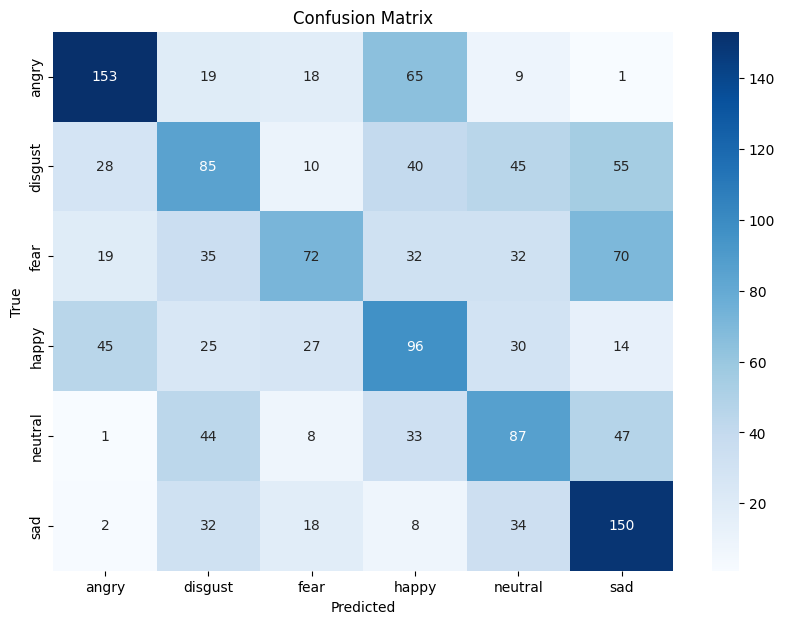

In [ ]:
import os
import librosa
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

def load_data_crema(dataset_path):
    emotions_crema = {
        "NEU": "neutral", "SAD": "sad", "ANG": "angry", "HAP": "happy",
        "DIS": "disgust", "FEA": "fear", "SUR": "surprise"
    }
    data = []
    labels = []

    crema_path = os.path.join(dataset_path, 'Crema')

    for subdir, dirs, files in os.walk(crema_path):
        for file in files:
            if file.endswith(".wav"):
                emotion_code = file.split("_")[2]

                if emotion_code not in emotions_crema:
                    continue

                emotion = emotions_crema[emotion_code]
                labels.append(emotion)

                filepath = os.path.join(subdir, file)
                signal, sr = librosa.load(filepath, sr=22050)

                mfcc = librosa.feature.mfcc(y=signal, sr=sr, n_mfcc=40)
                mfcc_scaled = np.mean(mfcc.T, axis=0)
                data.append(mfcc_scaled)

    return np.array(data), np.array(labels)

dataset_path = "/root/.cache/kagglehub/datasets/dmitrybabko/speech-emotion-recognition-en/versions/1"
data, labels = load_data_crema(dataset_path)

if data.shape[0] == 0:
    print("No data loaded. Please check the dataset and path.")
else:
    print(f"Data loaded: {data.shape[0]} samples")

label_encoder = LabelEncoder()
labels_encoded = label_encoder.fit_transform(labels)

X_train, X_test, y_train, y_test = train_test_split(data, labels_encoded, test_size=0.2, random_state=42)

model = Sequential()
model.add(LSTM(256, input_shape=(X_train.shape[1], 1), return_sequences=False))
model.add(Dropout(0.2))
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(len(np.unique(labels_encoded)), activation='softmax'))

model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

X_train = X_train[..., np.newaxis]
X_test = X_test[..., np.newaxis]

history = model.fit(X_train, y_train, epochs=50, batch_size=32, validation_data=(X_test, y_test))

y_pred = model.predict(X_test)
y_pred = np.argmax(y_pred, axis=1)

print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()


Model Creation and Training and Saving

Loading data from CSV file...
Data loaded: 7442 samples
Label encoder saved to 'label_encoder.pkl'.
Building and training new model...


/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/200
187/187 ━━━━━━━━━━━━━━━━━━━━ 32s 156ms/step - accuracy: 0.2082 - loss: 1.7657 - val_accuracy: 0.2841 - val_loss: 1.6768
Epoch 2/200
187/187 ━━━━━━━━━━━━━━━━━━━━ 25s 132ms/step - accuracy: 0.3123 - loss: 1.6346 - val_accuracy: 0.2760 - val_loss: 1.6227
Epoch 3/200
187/187 ━━━━━━━━━━━━━━━━━━━━ 42s 136ms/step - accuracy: 0.3430 - loss: 1.5597 - val_accuracy: 0.3392 - val_loss: 1.5257
Epoch 4/200
187/187 ━━━━━━━━━━━━━━━━━━━━ 25s 131ms/step - accuracy: 0.3476 - loss: 1.5381 - val_accuracy: 0.3660 - val_loss: 1.4904
Epoch 5/200
187/187 ━━━━━━━━━━━━━━━━━━━━ 41s 131ms/step - accuracy: 0.3562 - loss: 1.5208 - val_accuracy: 0.3741 - val_loss: 1.4898
Epoch 6/200
187/187 ━━━━━━━━━━━━━━━━━━━━ 41s 134ms/step - accuracy: 0.3804 - loss: 1.5042 - val_accuracy: 0.3351 - val_loss: 1.5622
Epoch 7/200
187/187 ━━━━━━━━━━━━━━━━━━━━ 41s 134ms/step - accuracy: 0.3527 - loss: 1.5319 - val_accuracy: 0.3936 - val_loss: 1.4495
Epoch 8/200
187/187 ━━━━━━━━━━━━━━━━━━━━ 41s 133ms/step - accuracy: 0.3955 -

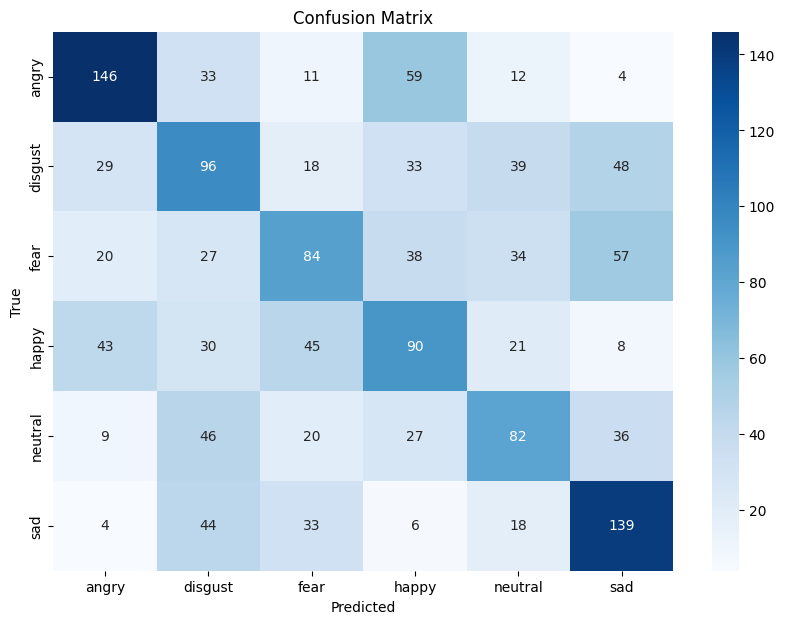

In [ ]:
import os
import librosa
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from keras.models import Sequential, load_model
from keras.layers import LSTM, Dense, Dropout
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import pickle

def load_or_extract_data_crema(dataset_path, csv_filename="crema_data.csv"):
    if os.path.exists(csv_filename):
        print("Loading data from CSV file...")
        data = pd.read_csv(csv_filename)
        features = data.drop("emotion", axis=1).values
        labels = data["emotion"].values
        return features, labels
    else:
        emotions_crema = {
            "NEU": "neutral", "SAD": "sad", "ANG": "angry", "HAP": "happy",
            "DIS": "disgust", "FEA": "fear", "SUR": "surprise"
        }
        data = []
        labels = []

        crema_path = os.path.join(dataset_path, 'Crema')

        for subdir, dirs, files in os.walk(crema_path):
            for file in files:
                if file.endswith(".wav"):
                    emotion_code = file.split("_")[2]

                    if emotion_code not in emotions_crema:
                        continue

                    emotion = emotions_crema[emotion_code]
                    labels.append(emotion)

                    filepath = os.path.join(subdir, file)
                    signal, sr = librosa.load(filepath, sr=22050)

                    mfcc = librosa.feature.mfcc(y=signal, sr=sr, n_mfcc=40)
                    mfcc_scaled = np.mean(mfcc.T, axis=0)
                    data.append(mfcc_scaled)

        data = np.array(data)
        labels = np.array(labels)

        df = pd.DataFrame(data)
        df["emotion"] = labels
        df.to_csv(csv_filename, index=False)
        print(f"Data saved to {csv_filename}")
        return data, labels

dataset_path = "/root/.cache/kagglehub/datasets/dmitrybabko/speech-emotion-recognition-en/versions/1"
data, labels = load_or_extract_data_crema(dataset_path)

if data.shape[0] == 0:
    print("No data loaded. Please check the dataset and path.")
else:
    print(f"Data loaded: {data.shape[0]} samples")

label_encoder = LabelEncoder()
labels_encoded = label_encoder.fit_transform(labels)

with open('label_encoder.pkl', 'wb') as f:
    pickle.dump(label_encoder, f)
    print("Label encoder saved to 'label_encoder.pkl'.")

X_train, X_test, y_train, y_test = train_test_split(data, labels_encoded, test_size=0.2, random_state=42)

model_filename = 'emotion_recognition_model.keras'

if os.path.exists(model_filename):
    print("Loading existing model...")
    model = load_model(model_filename)
else:
    print("Building and training new model...")
    model = Sequential()
    model.add(LSTM(256, input_shape=(X_train.shape[1], 1), return_sequences=False))
    model.add(Dropout(0.2))
    model.add(Dense(128, activation='relu'))
    model.add(Dropout(0.2))
    model.add(Dense(64, activation='relu'))
    model.add(Dropout(0.2))
    model.add(Dense(len(np.unique(labels_encoded)), activation='softmax'))

    model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

    X_train = X_train[..., np.newaxis]
    X_test = X_test[..., np.newaxis]

    history = model.fit(X_train, y_train, epochs=200, batch_size=32, validation_data=(X_test, y_test))

    model.save(model_filename)
    print(f"Model saved to {model_filename}")

y_pred = model.predict(X_test)
y_pred = np.argmax(y_pred, axis=1)

print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()


Prediction, Usage of Model

200 epoch model

In [ ]:
import os
import librosa
import numpy as np
from keras.models import load_model
import pickle

def load_label_encoder(encoder_file="label_encoder.pkl"):
    """Load the saved label encoder."""
    with open(encoder_file, 'rb') as f:
        label_encoder = pickle.load(f)
    return label_encoder

def extract_mfcc_features(file_path):
    """Extract MFCC features from an audio file."""
    signal, sr = librosa.load(file_path, sr=22050)
    mfcc = librosa.feature.mfcc(y=signal, sr=sr, n_mfcc=40)
    mfcc_scaled = np.mean(mfcc.T, axis=0)
    return mfcc_scaled

def predict_emotion(audio_file, model_filename="emotion_recognition_model.keras", encoder_filename="label_encoder.pkl"):
    """Predict the emotion of the given audio file."""

    if os.path.exists(model_filename):
        model = load_model(model_filename)
    else:
        print("Model file does not exist!")
        return None

    label_encoder = load_label_encoder(encoder_filename)

    mfcc_scaled = extract_mfcc_features(audio_file)

    mfcc_scaled = mfcc_scaled[np.newaxis, ..., np.newaxis]

    prediction = model.predict(mfcc_scaled)
    predicted_label_index = np.argmax(prediction, axis=1)

    predicted_emotion = label_encoder.inverse_transform(predicted_label_index)

    return predicted_emotion[0]

# Example usage: Sad
audio_file = "sad-voice.wav"
predicted_emotion = predict_emotion(audio_file)

if predicted_emotion:
    print(f"The predicted emotion for the audio file is: {predicted_emotion}")

# Example usage: Happy
audio_file = "happy-voice.wav"
predicted_emotion = predict_emotion(audio_file)

if predicted_emotion:
    print(f"The predicted emotion for the audio file is: {predicted_emotion}")


# Example usage: Angry
audio_file = "angry-voice.wav"
predicted_emotion = predict_emotion(audio_file)

if predicted_emotion:
    print(f"The predicted emotion for the audio file is: {predicted_emotion}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 234ms/step
The predicted emotion for the audio file is: sad
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 228ms/step
The predicted emotion for the audio file is: happy
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 223ms/step
The predicted emotion for the audio file is: fear


100 epoch model

In [ ]:
import os
import librosa
import numpy as np
from keras.models import load_model
import pickle

def load_label_encoder(encoder_file="label_encoder.pkl"):
    """Load the saved label encoder."""
    with open(encoder_file, 'rb') as f:
        label_encoder = pickle.load(f)
    return label_encoder

def extract_mfcc_features(file_path):
    """Extract MFCC features from an audio file."""
    signal, sr = librosa.load(file_path, sr=22050)
    mfcc = librosa.feature.mfcc(y=signal, sr=sr, n_mfcc=40)
    mfcc_scaled = np.mean(mfcc.T, axis=0)
    return mfcc_scaled

def predict_emotion(audio_file, model_filename="emotion_recognition_model_100epochs.keras", encoder_filename="label_encoder.pkl"):
    """Predict the emotion of the given audio file."""

    if os.path.exists(model_filename):
        model = load_model(model_filename)
    else:
        print("Model file does not exist!")
        return None

    label_encoder = load_label_encoder(encoder_filename)

    mfcc_scaled = extract_mfcc_features(audio_file)

    mfcc_scaled = mfcc_scaled[np.newaxis, ..., np.newaxis]

    prediction = model.predict(mfcc_scaled)
    predicted_label_index = np.argmax(prediction, axis=1)

    predicted_emotion = label_encoder.inverse_transform(predicted_label_index)

    return predicted_emotion[0]

# Example usage: Sad
audio_file = "sad-voice.wav"
predicted_emotion = predict_emotion(audio_file)

if predicted_emotion:
    print(f"The predicted emotion for the audio file is: {predicted_emotion}")

# Example usage: Happy
audio_file = "happy-voice.wav"
predicted_emotion = predict_emotion(audio_file)

if predicted_emotion:
    print(f"The predicted emotion for the audio file is: {predicted_emotion}")


# Example usage: Angry
audio_file = "angry-voice.wav"
predicted_emotion = predict_emotion(audio_file)

if predicted_emotion:
    print(f"The predicted emotion for the audio file is: {predicted_emotion}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 235ms/step
The predicted emotion for the audio file is: fear
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 184ms/step
The predicted emotion for the audio file is: happy
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 590ms/step
The predicted emotion for the audio file is: angry


NEW APPROACH: MULTIMODAL (TEXT + AUDIO WITH OTHER FEATURES AS WELL) MODEL

In [ ]:
pip install librosa scikit-learn tensorflow matplotlib seaborn pandas transformers


In [ ]:
pip install kagglehub

In [ ]:
import os
import librosa
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout
from sklearn.metrics import classification_report, confusion_matrix
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import BertTokenizer, TFBertModel


In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("zaber666/meld-dataset")

print("Path to dataset files:", path)

100%|██████████| 11.0G/11.0G [02:05<00:00, 93.9MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/zaber666/meld-dataset/versions/1


In [ ]:
import kagglehub

path = kagglehub.dataset_download("dmitrybabko/speech-emotion-recognition-en")

print("Path to dataset files:", path)

100%|██████████| 987M/987M [00:13<00:00, 75.1MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/dmitrybabko/speech-emotion-recognition-en/versions/1


In [ ]:
# Replace these with the actual paths to your datasets
crema_data_path = "/root/.cache/kagglehub/datasets/dmitrybabko/speech-emotion-recognition-en/versions/1/Crema"
meld_data_path = "/root/.cache/kagglehub/datasets/zaber666/meld-dataset/versions/1/MELD-RAW/MELD.Raw"


In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.utils import to_categorical


In [ ]:
# Function to extract features from an audio file
import librosa
import numpy as np

def extract_audio_features(file_path):
    signal, sr = librosa.load(file_path, sr=22050)

    # Extract MFCC
    mfccs = librosa.feature.mfcc(y=signal, sr=sr, n_mfcc=13)
    mfccs_scaled = np.mean(mfccs.T, axis=0)

    # Extract Chroma
    chroma = librosa.feature.chroma_stft(y=signal, sr=sr)
    chroma_scaled = np.mean(chroma.T, axis=0)

    # Extract Spectral Contrast
    spectral_contrast = librosa.feature.spectral_contrast(y=signal, sr=sr)
    spectral_contrast_scaled = np.mean(spectral_contrast.T, axis=0)

    # Extract Zero-Crossing Rate
    zcr = librosa.feature.zero_crossing_rate(y=signal)
    zcr_scaled = np.mean(zcr.T, axis=0)

    return np.concatenate([mfccs_scaled, chroma_scaled, spectral_contrast_scaled, zcr_scaled])


# Load all audio files from CREMA-D and extract features
audio_files = [os.path.join(root, file) for root, dirs, files in os.walk(crema_data_path) for file in files if file.endswith('.wav')]

# Extract features from each audio file
audio_features = np.array([extract_audio_features(audio_file) for audio_file in audio_files])

print(f"Audio features shape: {audio_features.shape}")


/usr/local/lib/python3.11/dist-packages/librosa/core/pitch.py:103: UserWarning: Trying to estimate tuning from empty frequency set.
  return pitch_tuning(


Audio features shape: (7442, 33)


In [ ]:
# Assume audio_features from earlier: shape (7442, 33)
# Extract emotion labels from CREMA-D filenames
audio_labels = [os.path.basename(f).split('_')[2] for f in audio_files]

# Encode labels
le_audio = LabelEncoder()
y_audio = le_audio.fit_transform(audio_labels)

# Split
X_train_audio, X_test_audio, y_train_audio, y_test_audio = train_test_split(
    audio_features, y_audio, test_size=0.2, random_state=42
)

# Train Random Forest
audio_model = RandomForestClassifier(n_estimators=100, random_state=42)
audio_model.fit(X_train_audio, y_train_audio)

# Evaluate
audio_preds = audio_model.predict(X_test_audio)
print("Audio Model Performance:")
print(classification_report(y_test_audio, audio_preds, target_names=le_audio.classes_))


Audio Model Performance:
              precision    recall  f1-score   support

         ANG       0.52      0.77      0.62       225
         DIS       0.39      0.31      0.35       254
         FEA       0.40      0.21      0.27       258
         HAP       0.40      0.35      0.38       262
         NEU       0.43      0.49      0.46       227
         SAD       0.49      0.61      0.54       263

    accuracy                           0.45      1489
   macro avg       0.44      0.46      0.44      1489
weighted avg       0.44      0.45      0.43      1489



In [ ]:
import os
import numpy as np
import pandas as pd
from transformers import BertTokenizer, TFBertModel
import tensorflow as tf
from tqdm import tqdm

# Load MELD text data
meld_df = pd.read_csv(os.path.join(meld_data_path, "test_sent_emo.csv"))

# Map the emotion labels to match CREMA-D
meld_df['emotion'] = meld_df['Emotion'].replace({
    'joy': 'happy',
    'sadness': 'sad',
    'anger': 'angry'
})

# Load tokenizer and model once
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
model = TFBertModel.from_pretrained('bert-base-uncased')

# Ensure model is in inference mode
_ = model(tf.constant(tokenizer(["test"], return_tensors="tf")["input_ids"]))

# Batch feature extraction
def extract_text_features_batch(texts, batch_size=32):
    embeddings = []

    for i in tqdm(range(0, len(texts), batch_size), desc="Extracting BERT features"):
        batch_texts = texts[i:i + batch_size].tolist()
        inputs = tokenizer(batch_texts, return_tensors='tf', padding=True, truncation=True, max_length=64)
        outputs = model(**inputs)
        pooled = tf.reduce_mean(outputs.last_hidden_state, axis=1)  # Mean pooling
        embeddings.append(pooled.numpy())

    return np.vstack(embeddings)

# Apply to MELD utterances
text_features = extract_text_features_batch(meld_df['Utterance'], batch_size=32)

print(f"Text features shape: {text_features.shape}")


Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFBertModel: ['cls.seq_relationship.weight', 'cls.predictions.transform.dense.bias', 'cls.seq_relationship.bias', 'cls.predictions.bias', 'cls.predictions.transform.LayerNorm.bias', 'cls.predictions.transform.LayerNorm.weight', 'cls.predictions.transform.dense.weight']
- This IS expected if you are initializing TFBertModel from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFBertModel from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
All the weights of TFBertModel were initialized from the PyTorch model.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFBertModel for predictions w

Text features shape: (2610, 768)


In [ ]:
# Assume text_features: (2610, 768)
# Assume meld_df['emotion'] already mapped to match CREMA-D

# Encode MELD emotion labels
le_text = LabelEncoder()
y_text = le_text.fit_transform(meld_df['Emotion'])

# One-hot encode for Keras
y_text_categorical = to_categorical(y_text)

# Train/Test split
X_train_text, X_test_text, y_train_text, y_test_text = train_test_split(
    text_features, y_text_categorical, test_size=0.2, random_state=42
)

# Define a simple neural net
text_model = Sequential([
    Dense(256, activation='relu', input_shape=(768,)),
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(y_text_categorical.shape[1], activation='softmax')
])

text_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
text_model.fit(X_train_text, y_train_text, epochs=10, batch_size=32, validation_split=0.1)

# Evaluate
text_preds = text_model.predict(X_test_text)
text_preds_classes = np.argmax(text_preds, axis=1)
y_test_text_classes = np.argmax(y_test_text, axis=1)

print("Text Model Performance:")
print(classification_report(y_test_text_classes, text_preds_classes, target_names=le_text.classes_))


Epoch 1/10


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


59/59 ━━━━━━━━━━━━━━━━━━━━ 4s 34ms/step - accuracy: 0.4686 - loss: 1.5167 - val_accuracy: 0.5694 - val_loss: 1.1981
Epoch 2/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5750 - loss: 1.2378 - val_accuracy: 0.5885 - val_loss: 1.1288
Epoch 3/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6008 - loss: 1.1269 - val_accuracy: 0.5981 - val_loss: 1.1790
Epoch 4/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6296 - loss: 1.0752 - val_accuracy: 0.6172 - val_loss: 1.1210
Epoch 5/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6490 - loss: 1.0420 - val_accuracy: 0.5933 - val_loss: 1.1113
Epoch 6/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6619 - loss: 0.9731 - val_accuracy: 0.6316 - val_loss: 1.1106
Epoch 7/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6856 - loss: 0.9212 - val_accuracy: 0.6220 - val_loss: 1.0824
Epoch 8/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6998 - loss: 0.8578 - val_accuracy: 0.6411 - val_loss: 1.1251
Ep

In [ ]:
import os
import numpy as np
import librosa
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
import joblib
from tqdm import tqdm

# Label map based on filename tags
label_map = {
    'ANG': 'angry',
    'DIS': 'disgust',
    'FEA': 'fear',
    'HAP': 'happy',
    'NEU': 'neutral',
    'SAD': 'sad'
}

# Feature extraction function

def extract_audio_features(file_path, max_pad_len=862):
    try:
        y, sr = librosa.load(file_path, sr=None)
        mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=40)

        # Ensure consistent shape: (40, max_pad_len)
        if mfccs.shape[1] < max_pad_len:
            pad_width = max_pad_len - mfccs.shape[1]
            mfccs = np.pad(mfccs, pad_width=((0, 0), (0, pad_width)), mode='constant')
        else:
            mfccs = mfccs[:, :max_pad_len]

        return mfccs.flatten()  # returns 1D array of shape (40 * max_pad_len,)
    except Exception as e:
        print(f"Error in extract_audio_features for {file_path}: {e}")
        return None


# Load all .wav files and extract features + labels
audio_features = []
audio_labels = []

print("Processing audio files...")
audio_features = []
audio_labels = []

for root, _, files in os.walk(crema_data_path):
    for file in tqdm(files):
        if file.endswith('.wav'):
            try:
                filepath = os.path.join(root, file)
                tag = file.split('_')[2]  # e.g., 'ANG' from '1090_TAI_ANG_XX.wav'
                label = label_map.get(tag)
                if label:
                    features = extract_audio_features(filepath)
                    if features is not None:  # Skip if feature extraction failed
                        audio_features.append(features)
                        audio_labels.append(label)
            except Exception as e:
                print(f"Error processing {file}: {e}")


audio_features = np.array(audio_features)
audio_labels = np.array(audio_labels)

print(f"Extracted {len(audio_features)} feature vectors")

X_audio = np.array(audio_features)
y_audio = np.array(audio_labels)

print("Audio features shape:", X_audio.shape)
print("Audio labels shape:", y_audio.shape)


# Encode labels numerically
le = LabelEncoder()
encoded_labels = le.fit_transform(audio_labels)

# Split and train
X_train, X_test, y_train, y_test = train_test_split(audio_features, encoded_labels, test_size=0.2, random_state=42)


# Use RandomForestClassifier for fast and strong performance
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

# Evaluate
y_pred = clf.predict(X_test)
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

# Save the audio model and label encoder
joblib.dump(clf, "audio_emotion_model.keras")
joblib.dump(le, "audio_label_encoder.pkl")

print("Audio model and encoder saved.")


Processing audio files...


100%|██████████| 7442/7442 [01:00<00:00, 123.25it/s]


Extracted 7442 feature vectors
Audio features shape: (7442, 34480)
Audio labels shape: (7442,)
Classification Report:
              precision    recall  f1-score   support

       angry       0.53      0.75      0.62       225
     disgust       0.37      0.38      0.38       254
        fear       0.37      0.19      0.26       258
       happy       0.43      0.42      0.42       262
     neutral       0.46      0.36      0.40       227
         sad       0.49      0.64      0.56       263

    accuracy                           0.45      1489
   macro avg       0.44      0.46      0.44      1489
weighted avg       0.44      0.45      0.44      1489

Audio model and encoder saved.


In [ ]:
from transformers import BertTokenizer, TFBertModel
import tensorflow as tf
import numpy as np

# Load MELD text data
meld_df = pd.read_csv(os.path.join(meld_data_path, "test_sent_emo.csv"))
meld_df['emotion'] = meld_df['Emotion'].replace({
    'joy': 'happy',
    'sadness': 'sad',
    'anger': 'angry'
})

# Tokenizer and BERT model loading
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
model = TFBertModel.from_pretrained('bert-base-uncased')

# Batch feature extraction
def extract_text_features_batch(texts, batch_size=32):
    embeddings = []
    for i in range(0, len(texts), batch_size):
        batch_texts = texts[i:i + batch_size].tolist()
        inputs = tokenizer(batch_texts, return_tensors='tf', padding=True, truncation=True, max_length=64)
        outputs = model(**inputs)
        pooled = tf.reduce_mean(outputs.last_hidden_state, axis=1)  # Mean pooling
        embeddings.append(pooled.numpy())
    return np.vstack(embeddings)

# Extract BERT text features
text_features = extract_text_features_batch(meld_df['Utterance'], batch_size=32)

# Encode emotion labels
text_labels = meld_df['emotion'].values
label_encoder_text = LabelEncoder()
encoded_labels_text = label_encoder_text.fit_transform(text_labels)

# Split the dataset into training and testing
X_train_text, X_test_text, y_train_text, y_test_text = train_test_split(text_features, encoded_labels_text, test_size=0.2, random_state=42)

# Build the text model
text_model = models.Sequential([
    layers.Dense(64, activation='relu', input_dim=X_train_text.shape[1]),
    layers.Dropout(0.2),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(len(label_encoder_text.classes_), activation='softmax')
])

text_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Train the text model
text_model.fit(X_train_text, y_train_text, epochs=100, batch_size=32, validation_data=(X_test_text, y_test_text))

# Save the text model
text_model.save('text_model.keras')


Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFBertModel: ['cls.seq_relationship.weight', 'cls.predictions.transform.dense.bias', 'cls.seq_relationship.bias', 'cls.predictions.bias', 'cls.predictions.transform.LayerNorm.bias', 'cls.predictions.transform.LayerNorm.weight', 'cls.predictions.transform.dense.weight']
- This IS expected if you are initializing TFBertModel from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFBertModel from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
All the weights of TFBertModel were initialized from the PyTorch model.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFBertModel for predictions w

Epoch 1/100


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


66/66 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step - accuracy: 0.3892 - loss: 1.6692 - val_accuracy: 0.5632 - val_loss: 1.2500
Epoch 2/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.5325 - loss: 1.3424 - val_accuracy: 0.6034 - val_loss: 1.1621
Epoch 3/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5885 - loss: 1.2212 - val_accuracy: 0.6303 - val_loss: 1.1008
Epoch 4/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6230 - loss: 1.1514 - val_accuracy: 0.6284 - val_loss: 1.0867
Epoch 5/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6188 - loss: 1.0901 - val_accuracy: 0.6398 - val_loss: 1.0393
Epoch 6/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.6165 - loss: 1.0945 - val_accuracy: 0.6552 - val_loss: 1.0388
Epoch 7/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6382 - loss: 1.0705 - val_accuracy: 0.6475 - val_loss: 1.0309
Epoch 8/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6729 - loss: 0.9754 - val_accuracy: 0.6571 - val_loss: 1.

17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
Classification Report:
              precision    recall  f1-score   support

       angry       0.43      0.45      0.44        71
     disgust       0.27      0.23      0.25        13
        fear       0.25      0.33      0.29         3
       happy       0.52      0.54      0.53        69
     neutral       0.71      0.75      0.73       251
         sad       0.29      0.24      0.26        50
    surprise       0.53      0.45      0.48        65

    accuracy                           0.58       522
   macro avg       0.43      0.43      0.43       522
weighted avg       0.57      0.58      0.58       522



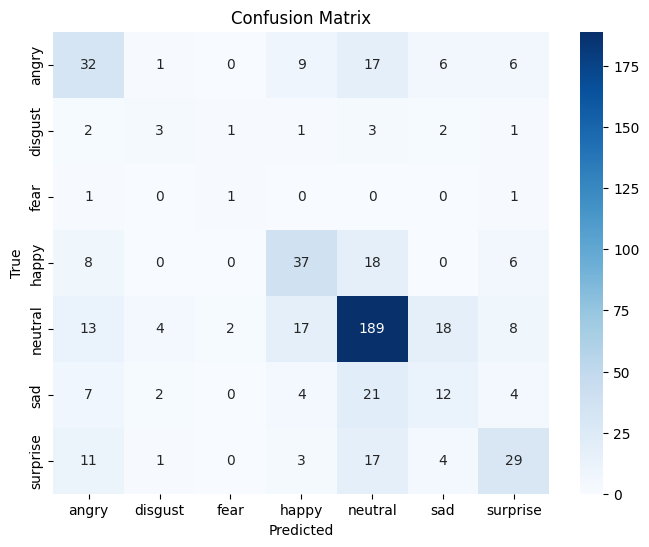

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Predict class probabilities
y_probs = text_model.predict(X_test_text)

# Convert probabilities to predicted class indices
y_pred = np.argmax(y_probs, axis=1)

# Classification Report
print("Classification Report:")
print(classification_report(y_test_text, y_pred, target_names=label_encoder_text.classes_))

# Confusion Matrix
cm = confusion_matrix(y_test_text, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder_text.classes_,
            yticklabels=label_encoder_text.classes_)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()


In [ ]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from transformers import BertTokenizer, TFBertModel
from tensorflow.keras import models, layers
from tqdm import tqdm

# Load MELD text data
meld_df = pd.read_csv(os.path.join(meld_data_path, "test_sent_emo.csv"))

# Standardize emotion labels
meld_df['emotion'] = meld_df['Emotion'].replace({
    'joy': 'happy',
    'sadness': 'sad',
    'anger': 'angry'
})

# Remove 'surprise' class
meld_df = meld_df[meld_df['emotion'] != 'surprise']

# Load tokenizer and BERT model
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
model = TFBertModel.from_pretrained('bert-base-uncased')

# Batch feature extraction
def extract_text_features_batch(texts, batch_size=32):
    embeddings = []
    for i in tqdm(range(0, len(texts), batch_size), desc="Extracting BERT features"):
        batch_texts = texts[i:i + batch_size].tolist()
        inputs = tokenizer(batch_texts, return_tensors='tf', padding=True, truncation=True, max_length=64)
        outputs = model(**inputs)
        pooled = tf.reduce_mean(outputs.last_hidden_state, axis=1)
        embeddings.append(pooled.numpy())
    return np.vstack(embeddings)

# Extract BERT text features
text_features = extract_text_features_batch(meld_df['Utterance'], batch_size=32)

# Encode emotion labels
text_labels = meld_df['emotion'].values
label_encoder_text = LabelEncoder()
encoded_labels_text = label_encoder_text.fit_transform(text_labels)

# Split dataset
X_train_text, X_test_text, y_train_text, y_test_text = train_test_split(
    text_features, encoded_labels_text, test_size=0.2, random_state=42
)

# Compute class weights
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_text),
    y=y_train_text
)
class_weight_dict = dict(enumerate(class_weights))

# Build the text model
text_model = models.Sequential([
    layers.Dense(64, activation='relu', input_dim=X_train_text.shape[1]),
    layers.Dropout(0.2),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(len(label_encoder_text.classes_), activation='softmax')
])

text_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Train the model using class weights
text_model.fit(
    X_train_text, y_train_text,
    epochs=100,
    batch_size=32,
    validation_data=(X_test_text, y_test_text),
    class_weight=class_weight_dict
)

# Save the model
text_model.save('text_model.keras')

# Save label encoder
import pickle
with open('text_label_encoder.pkl', 'wb') as f:
    pickle.dump(label_encoder_text, f)


Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFBertModel: ['cls.seq_relationship.weight', 'cls.predictions.transform.dense.bias', 'cls.seq_relationship.bias', 'cls.predictions.bias', 'cls.predictions.transform.LayerNorm.bias', 'cls.predictions.transform.LayerNorm.weight', 'cls.predictions.transform.dense.weight']
- This IS expected if you are initializing TFBertModel from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFBertModel from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
All the weights of TFBertModel were initialized from the PyTorch model.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFBertModel for predictions w

Epoch 1/100



/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


59/59 ━━━━━━━━━━━━━━━━━━━━ 5s 52ms/step - accuracy: 0.1676 - loss: 1.7399 - val_accuracy: 0.3369 - val_loss: 1.6890
Epoch 2/100
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.3637 - loss: 1.6155 - val_accuracy: 0.4549 - val_loss: 1.4871
Epoch 3/100
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4656 - loss: 1.4959 - val_accuracy: 0.5150 - val_loss: 1.3727
Epoch 4/100
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5231 - loss: 1.3904 - val_accuracy: 0.5150 - val_loss: 1.3254
Epoch 5/100
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5224 - loss: 1.3492 - val_accuracy: 0.5279 - val_loss: 1.2595
Epoch 6/100
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5183 - loss: 1.2962 - val_accuracy: 0.5150 - val_loss: 1.3276
Epoch 7/100
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5470 - loss: 1.2281 - val_accuracy: 0.5386 - val_loss: 1.2739
Epoch 8/100
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5301 - loss: 1.2631 - val_accuracy: 0.5429 - val_loss: 1.

15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step
Classification Report:
              precision    recall  f1-score   support

       angry       0.44      0.41      0.43        68
     disgust       0.00      0.00      0.00        11
        fear       0.22      0.22      0.22         9
       happy       0.40      0.59      0.48        69
     neutral       0.74      0.62      0.68       262
         sad       0.24      0.32      0.28        47

    accuracy                           0.53       466
   macro avg       0.34      0.36      0.35       466
weighted avg       0.57      0.53      0.55       466



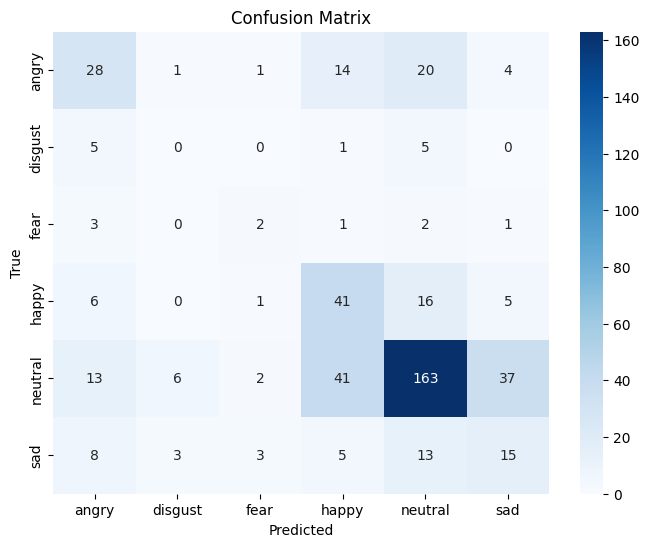

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Predict class probabilities
y_probs = text_model.predict(X_test_text)

# Convert probabilities to predicted class indices
y_pred = np.argmax(y_probs, axis=1)

# Classification Report
print("Classification Report:")
print(classification_report(y_test_text, y_pred, target_names=label_encoder_text.classes_))

# Confusion Matrix
cm = confusion_matrix(y_test_text, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder_text.classes_,
            yticklabels=label_encoder_text.classes_)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()


In [ ]:
!pip install --upgrade --quiet SpeechRecognition


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 32.9/32.9 MB 17.1 MB/s eta 0:00:00


In [ ]:
import speech_recognition as sr
import librosa
import numpy as np
from transformers import BertTokenizer, TFBertModel
import tensorflow as tf

# Load the models
audio_model = tf.keras.models.load_model('/content/audio_model.keras')
text_model = tf.keras.models.load_model('/content/text_model.keras')

# Load the BERT tokenizer and model for text processing
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
bert_model = TFBertModel.from_pretrained('bert-base-uncased')

# Function to transcribe audio to text
def transcribe_audio(audio_file):
    recognizer = sr.Recognizer()
    with sr.AudioFile(audio_file) as source:
        audio = recognizer.record(source)
    try:
        return recognizer.recognize_google(audio)
    except sr.UnknownValueError:
        return ""
    except sr.RequestError:
        return ""

# Function to extract audio features
def extract_audio_features(file_path):
    signal, sr = librosa.load(file_path, sr=22050)
    mfccs = librosa.feature.mfcc(y=signal, sr=sr, n_mfcc=13)
    mfccs_scaled = np.mean(mfccs.T, axis=0)
    chroma = librosa.feature.chroma_stft(y=signal, sr=sr)
    chroma_scaled = np.mean(chroma.T, axis=0)
    spectral_contrast = librosa.feature.spectral_contrast(y=signal, sr=sr)
    spectral_contrast_scaled = np.mean(spectral_contrast.T, axis=0)
    zcr = librosa.feature.zero_crossing_rate(y=signal)
    zcr_scaled = np.mean(zcr.T, axis=0)
    return np.concatenate([mfccs_scaled, chroma_scaled, spectral_contrast_scaled, zcr_scaled])

# Function to extract text features using BERT
def extract_text_features(text):
    inputs = tokenizer(text, return_tensors='tf', padding=True, truncation=True, max_length=64)
    outputs = bert_model(**inputs)
    pooled = tf.reduce_mean(outputs.last_hidden_state, axis=1)  # Mean pooling
    return pooled.numpy()

# Predict using both models
def predict_emotion(audio_file):
    # Transcribe the audio
    transcription = transcribe_audio(audio_file)

    if transcription == "":
        print("Error: Could not transcribe audio.")
        return None

    # Extract audio features
    audio_features = extract_audio_features(audio_file).reshape(1, -1)
    audio_prediction = audio_model.predict(audio_features)

    # Extract text features
    text_features = extract_text_features(transcription)
    text_prediction = text_model.predict(text_features)

    # Combine predictions (average the probabilities from both models)
    combined_prediction = (audio_prediction + text_prediction) / 2
    final_prediction = np.argmax(combined_prediction, axis=1)

    # Decode the final prediction
    # Load the label encoder
    with open('/content/text_label_encoder.pkl', 'rb') as f:
        label_encoder_text = pickle.load(f)

    # Then decode prediction
    predicted_label = label_encoder_text.inverse_transform([final_prediction])[0]

    return predicted_label

# Example usage
audio_file = "/happy-voice.wav"
emotion = predict_emotion(audio_file)
print(f"Predicted emotion: {emotion}")


Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFBertModel: ['cls.seq_relationship.weight', 'cls.predictions.transform.dense.bias', 'cls.seq_relationship.bias', 'cls.predictions.bias', 'cls.predictions.transform.LayerNorm.bias', 'cls.predictions.transform.LayerNorm.weight', 'cls.predictions.transform.dense.weight']
- This IS expected if you are initializing TFBertModel from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFBertModel from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
All the weights of TFBertModel were initialized from the PyTorch model.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFBertModel for predictions w

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 212ms/step
Predicted emotion: happy


/usr/local/lib/python3.11/dist-packages/sklearn/preprocessing/_label.py:151: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


NEW DATASET

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("dejolilandry/iemocapfullrelease")

print("Path to dataset files:", path)

100%|██████████| 11.5G/11.5G [06:39<00:00, 31.0MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/dejolilandry/iemocapfullrelease/versions/1


In [ ]:
import os
import random
import pickle
import joblib
import librosa
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import soundfile as sf
from pydub import AudioSegment
from pydub.utils import make_chunks
import speech_recognition as sr

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout, LSTM, Bidirectional, Conv1D, MaxPooling1D, Flatten, concatenate, Embedding, BatchNormalization
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import AdamW


In [ ]:
# Load the CSV file
df = pd.read_csv('/root/.cache/kagglehub/datasets/samuelsamsudinng/iemocap-emotion-speech-database/versions/1/iemocap_full_dataset.csv')  # Replace with your actual CSV file path

# Display the first few rows
print(df.head())

   session  method gender emotion  n_annotators  agreement  \
0        1  script      F     neu             3          3   
1        1  script      F     fru             3          2   
2        1  script      F     xxx             0          0   
3        1  script      F     sur             3          2   
4        1  script      F     neu             3          2   

                                                path  
0  Session1/sentences/wav/Ses01F_script02_1/Ses01...  
1  Session1/sentences/wav/Ses01F_script02_1/Ses01...  
2  Session1/sentences/wav/Ses01F_script02_1/Ses01...  
3  Session1/sentences/wav/Ses01F_script02_1/Ses01...  
4  Session1/sentences/wav/Ses01F_script02_1/Ses01...  


In [ ]:
# Filter out invalid labels (less than 9)
df = df[df['emotion'].notna()]
df = df[df['emotion'] != 'xxx']  # Remove unknowns if present
df = df.reset_index(drop=True)

# Encode emotion labels
label_encoder = LabelEncoder()
df['label'] = label_encoder.fit_transform(df['emotion'])

# Save encoder
with open('label_encoder.pkl', 'wb') as f:
    pickle.dump(label_encoder, f)

print("Encoded labels:", label_encoder.classes_)


Encoded labels: ['ang' 'dis' 'exc' 'fea' 'fru' 'hap' 'neu' 'oth' 'sad' 'sur']


In [ ]:
def extract_audio_features(file_path, sr=22050, duration=3):
    try:
        audio, sample_rate = librosa.load(file_path, sr=sr, duration=duration)
        if len(audio) < sr * duration:
            padding = sr * duration - len(audio)
            audio = np.pad(audio, (0, int(padding)), 'constant')
        else:
            audio = audio[:sr * duration]

        mfccs = librosa.feature.mfcc(y=audio, sr=sample_rate, n_mfcc=40)
        chroma = librosa.feature.chroma_stft(y=audio, sr=sample_rate)
        mel = librosa.feature.melspectrogram(y=audio, sr=sample_rate)
        contrast = librosa.feature.spectral_contrast(y=audio, sr=sample_rate)
        tonnetz = librosa.feature.tonnetz(y=librosa.effects.harmonic(audio), sr=sample_rate)

        features = np.hstack([
            np.mean(mfccs, axis=1),
            np.mean(chroma, axis=1),
            np.mean(mel, axis=1),
            np.mean(contrast, axis=1),
            np.mean(tonnetz, axis=1)
        ])
        return features
    except Exception as e:
        print(f"Error processing {file_path}: {e}")
        return None

def transcribe_audio(file_path, chunk_length_ms=10000):
    recognizer = sr.Recognizer()
    try:
        audio = AudioSegment.from_file(file_path).set_channels(1).set_frame_rate(16000)
        chunks = make_chunks(audio, chunk_length_ms)
        transcript = ""
        for i, chunk in enumerate(chunks):
            chunk_filename = f"chunk_{i}.wav"
            chunk.export(chunk_filename, format="wav")
            with sr.AudioFile(chunk_filename) as source:
                audio_data = recognizer.record(source)
                try:
                    text = recognizer.recognize_google(audio_data)
                    transcript += text + " "
                except sr.UnknownValueError:
                    continue
                except sr.RequestError as e:
                    print(f"API error: {e}")
                    return ""
            os.remove(chunk_filename)
        return transcript.strip()
    except Exception as e:
        print(f"Error transcribing {file_path}: {e}")
        return ""


In [ ]:
BASE_AUDIO_DIR = '/root/.cache/kagglehub/datasets/dejolilandry/iemocapfullrelease/versions/1/IEMOCAP_full_release'  # Change this to the actual location


subset_df = df.sample(n=500, random_state=42).reset_index(drop=True)

audio_features, transcriptions, labels = [], [], []

for _, row in subset_df.iterrows():
    relative_path = row['path']
    absolute_path = os.path.join(BASE_AUDIO_DIR, relative_path)

    if not os.path.exists(absolute_path):
        print(f"Missing: {absolute_path}")
        continue

    features = extract_audio_features(absolute_path)
    if features is None:
        continue

    transcription = transcribe_audio(absolute_path)

    audio_features.append(features)
    transcriptions.append(transcription)
    labels.append(row['label'])

print(f"Samples collected: {len(audio_features)}")


Samples collected: 500


In [ ]:
# Tokenize and pad
tokenizer = Tokenizer(num_words=5000, oov_token='<OOV>')
tokenizer.fit_on_texts(transcriptions)
sequences = tokenizer.texts_to_sequences(transcriptions)
padded_sequences = pad_sequences(sequences, maxlen=100, padding='post')

with open('tokenizer.pkl', 'wb') as f:
    pickle.dump(tokenizer, f)

# Encode labels
le = LabelEncoder()
encoded_labels = le.fit_transform(labels)
joblib.dump(le, 'label_encoder.pkl')

# Final arrays
X_audio = np.array(audio_features)
X_text = np.array(padded_sequences)
y = np.array(encoded_labels)


In [ ]:
X_audio_train, X_audio_test, X_text_train, X_text_test, y_train, y_test = train_test_split(
    X_audio, X_text, y, test_size=0.2, random_state=42
)


In [ ]:
# Input shapes
audio_input = Input(shape=(X_audio.shape[1],))
text_input = Input(shape=(X_text.shape[1],))

# Audio branch
x_audio = Dense(128, activation='relu')(audio_input)
x_audio = Dropout(0.3)(x_audio)
x_audio = Dense(64, activation='relu')(x_audio)
x_audio = Dropout(0.3)(x_audio)

# Text branch
x_text = Embedding(input_dim=5000, output_dim=128, input_length=X_text.shape[1])(text_input)
x_text = Conv1D(64, kernel_size=5, activation='relu')(x_text)
x_text = MaxPooling1D(pool_size=2)(x_text)
x_text = Bidirectional(LSTM(64))(x_text)
x_text = Dropout(0.3)(x_text)

# Combined
combined = concatenate([x_audio, x_text])
x = Dense(128, activation='relu')(combined)
x = BatchNormalization()(x)
x = Dropout(0.4)(x)
x = Dense(64, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.4)(x)

output = Dense(len(le.classes_), activation='softmax')(x)

model = Model(inputs=[audio_input, text_input], outputs=output)
model.compile(optimizer=AdamW(learning_rate=1e-4, weight_decay=1e-5),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "functional_13"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_31      │ (None, 100)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_30      │ (None, 193)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_14        │ (None, 100, 128)  │    640,000 │ input_layer_31[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_69 (Dense)    │ (None, 128)       │     24,832 │ input_layer_30[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_14 (Conv1D)  │ (None, 96, 64)    │     41,024 │ embedding_14[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_70          │ (None, 128)       │          0 │ dense_69[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_14    │ (None, 48, 64)    │          0 │ conv1d_14[0][0]   │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_70 (Dense)    │ (None, 64)        │      8,256 │ dropout_70[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_14    │ (None, 128)       │     66,048 │ max_pooling1d_14… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_71          │ (None, 64)        │          0 │ dense_70[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_72          │ (None, 128)       │          0 │ bidirectional_14… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_14      │ (None, 192)       │          0 │ dropout_71[0][0], │
│ (Concatenate)       │                   │            │ dropout_72[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_71 (Dense)    │ (None, 128)       │     24,704 │ concatenate_14[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128)       │        512 │ dense_71[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_73          │ (None, 128)       │          0 │ batch_normalizat… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_72 (Dense)    │ (None, 64)        │      8,256 │ dropout_73[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64)        │        256 │ dense_72[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_74          │ (None, 64)        │          0 │ batch_normalizat… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 814,473 (3.11 MB)

 Trainable params: 814,089 (3.11 MB)

 Non-trainable params: 384 (1.50 KB)

In [ ]:
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)

history = model.fit(
    [X_audio_train, X_text_train], y_train,
    epochs=50, batch_size=32,
    validation_data=([X_audio_test, X_text_test], y_test),
    callbacks=[early_stop, reduce_lr]
)


Epoch 1/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 191ms/step - accuracy: 0.1351 - loss: 2.8818 - val_accuracy: 0.2800 - val_loss: 2.2166 - learning_rate: 5.0000e-05
Epoch 2/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 170ms/step - accuracy: 0.1487 - loss: 2.9712 - val_accuracy: 0.2800 - val_loss: 2.2118 - learning_rate: 5.0000e-05
Epoch 3/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 84ms/step - accuracy: 0.1471 - loss: 2.8292 - val_accuracy: 0.2800 - val_loss: 2.2075 - learning_rate: 5.0000e-05
Epoch 4/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 96ms/step - accuracy: 0.1103 - loss: 2.8842 - val_accuracy: 0.2700 - val_loss: 2.2075 - learning_rate: 5.0000e-05
Epoch 5/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 136ms/step - accuracy: 0.1307 - loss: 2.9765 - val_accuracy: 0.2700 - val_loss: 2.2047 - learning_rate: 5.0000e-05
Epoch 6/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 101ms/step - accuracy: 0.1418 - loss: 2.8866 - val_accuracy: 0.2700 - val_loss: 2.2041 - learning_rate: 5.0000e-05
Epoch 7/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 79ms/step - accuracy: 0.1

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

# Predict class probabilities
y_pred_probs = model.predict([X_audio_test, X_text_test])
y_pred = np.argmax(y_pred_probs, axis=1)

# Get the actual class names from the labels used
unique_labels = np.unique(y_test)
target_names = [label_encoder.classes_[i] for i in unique_labels]

# Classification report
print("Classification Report:\n")
print(classification_report(y_test, y_pred, target_names=target_names))

# Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
Classification Report:

              precision    recall  f1-score   support

         ang       0.24      0.89      0.38        19
         exc       0.00      0.00      0.00         8
         fru       0.00      0.00      0.00        24
         hap       0.00      0.00      0.00         9
         neu       0.33      0.45      0.38        22
         oth       0.00      0.00      0.00        16
         sad       0.00      0.00      0.00         2

    accuracy                           0.27       100
   macro avg       0.08      0.19      0.11       100
weighted avg       0.12      0.27      0.16       100


Confusion Matrix:
[[17  0  0  0  2  0  0]
 [ 7  0  0  0  1  0  0]
 [18  0  0  0  6  0  0]
 [ 6  0  0  0  3  0  0]
 [12  0  0  0 10  0  0]
 [ 9  0  0  0  7  0  0]
 [ 1  0  0  0  1  0  0]]


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
# Save the trained model
model.save('multimodal_emotion_model.keras')


In [ ]:
import os
import librosa
import numpy as np
import speech_recognition as sr
import tensorflow as tf
import joblib
from transformers import BertTokenizer, TFBertModel

# Paths to saved models
MODEL_PATH = 'multimodal_emotion_model.keras'
LABEL_ENCODER_PATH = 'label_encoder.pkl'

# Load label encoder
from sklearn.preprocessing import LabelEncoder
label_encoder = joblib.load(LABEL_ENCODER_PATH)

# Load tokenizer and BERT
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
bert_model = TFBertModel.from_pretrained('bert-base-uncased')

# Load trained model
model = tf.keras.models.load_model(MODEL_PATH)

# --- Audio feature extraction ---
def extract_audio_features(file_path, sr=22050, duration=3):
    try:
        audio, sample_rate = librosa.load(file_path, sr=sr, duration=duration)
        if len(audio) < sr * duration:
            padding = sr * duration - len(audio)
            audio = np.pad(audio, (0, int(padding)), 'constant')
        else:
            audio = audio[:sr * duration]

        # Extract features
        mfccs = librosa.feature.mfcc(y=audio, sr=sample_rate, n_mfcc=40)
        chroma = librosa.feature.chroma_stft(y=audio, sr=sample_rate)
        mel = librosa.feature.melspectrogram(y=audio, sr=sample_rate)
        contrast = librosa.feature.spectral_contrast(y=audio, sr=sample_rate)
        tonnetz = librosa.feature.tonnetz(y=librosa.effects.harmonic(audio), sr=sample_rate)

        # Aggregate features
        features = np.hstack([
            np.mean(mfccs, axis=1),
            np.mean(chroma, axis=1),
            np.mean(mel, axis=1),
            np.mean(contrast, axis=1),
            np.mean(tonnetz, axis=1)
        ])
        return features
    except Exception as e:
        print(f"Error processing {file_path}: {e}")
        return None


# --- Audio transcription ---
def transcribe_audio(file_path):
    recognizer = sr.Recognizer()
    try:
        with sr.AudioFile(file_path) as source:
            audio_data = recognizer.record(source)
            text = recognizer.recognize_google(audio_data)
            return text
    except Exception as e:
        print(f"Error transcribing {file_path}: {e}")
        return ""


# --- BERT text embedding ---
def get_bert_text_embedding(text):
    inputs = tokenizer(text, return_tensors='tf', padding=True, truncation=True, max_length=64)
    outputs = bert_model(**inputs)
    pooled_output = tf.reduce_mean(outputs.last_hidden_state, axis=1)
    return pooled_output.numpy().squeeze()

# --- Make prediction ---
def predict_emotion(audio_path):
    audio_features = extract_audio_features(audio_path)
    transcription = transcribe_audio(audio_path)

    if not transcription:
        print("Could not transcribe audio.")
        return None

    text_embedding = get_bert_text_embedding(transcription)

    # Concatenate audio and text features
    combined = np.concatenate([audio_features, text_embedding])
    combined = combined.reshape(1, -1)

    prediction = model.predict(combined)
    predicted_class = np.argmax(prediction, axis=1)
    emotion = label_encoder.inverse_transform(predicted_class)[0]

    print(f"Transcription: {transcription}")
    print(f"Predicted Emotion: {emotion}")
    return emotion


In [ ]:
audio_path = "path/to/test_audio.wav"
predict_emotion(audio_path)


refactored this approach a little

In [ ]:
import os
import numpy as np
import pandas as pd
import librosa
import soundfile as sf
import random
import pickle
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Input, Dense, Dropout, Embedding, Conv1D,
                                     MaxPooling1D, LSTM, Bidirectional, Flatten, concatenate, BatchNormalization)
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import AdamW


In [ ]:
# Load CSV
df = pd.read_csv('/root/.cache/kagglehub/datasets/samuelsamsudinng/iemocap-emotion-speech-database/versions/1/iemocap_full_dataset.csv')
df = df[df['emotion'].notna()]  # Drop rows with missing emotion

# Encode emotion labels
label_encoder = LabelEncoder()
df['label'] = label_encoder.fit_transform(df['emotion'])

# Save encoder
with open('label_encoder.pkl', 'wb') as f:
    pickle.dump(label_encoder, f)

# Balance dataset (e.g., 150 samples per class)
samples_per_class = 150
balanced_df = df.groupby('label').apply(lambda x: x.sample(n=min(samples_per_class, len(x)), random_state=42)).reset_index(drop=True)

print(balanced_df['emotion'].value_counts())


emotion
ang    150
exc    150
fru    150
xxx    150
hap    150
neu    150
sad    150
sur    107
fea     40
oth      3
dis      2
Name: count, dtype: int64


<ipython-input-123-2abe355b500f>:15: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  balanced_df = df.groupby('label').apply(lambda x: x.sample(n=min(samples_per_class, len(x)), random_state=42)).reset_index(drop=True)


In [ ]:
def extract_audio_features(file_path, sr=22050, duration=3):
    try:
        audio, sample_rate = librosa.load(file_path, sr=sr, duration=duration)
        if len(audio) < sr * duration:
            padding = sr * duration - len(audio)
            audio = np.pad(audio, (0, int(padding)), 'constant')
        else:
            audio = audio[:sr * duration]

        mfccs = librosa.feature.mfcc(y=audio, sr=sample_rate, n_mfcc=40)
        return np.mean(mfccs, axis=1)  # Simpler features for performance
    except Exception as e:
        print(f"Error with {file_path}: {e}")
        return None


In [ ]:
BASE_AUDIO_DIR = '/root/.cache/kagglehub/datasets/dejolilandry/iemocapfullrelease/versions/1/IEMOCAP_full_release'

audio_features = []
text_transcriptions = []
valid_labels = []

for idx, row in balanced_df.iterrows():
    path = os.path.join(BASE_AUDIO_DIR, row['path'])
    if not os.path.exists(path): continue

    features = extract_audio_features(path)
    if features is None: continue

    # MOCK TRANSCRIPTION: use emotion name + dummy text to simulate transcription
    dummy_transcription = f"This speaker is expressing {row['emotion']} emotion."

    audio_features.append(features)
    text_transcriptions.append(dummy_transcription)
    valid_labels.append(row['label'])

print(f"Total samples used: {len(audio_features)}")


Total samples used: 1202


In [ ]:
tokenizer = Tokenizer(num_words=5000, oov_token='<OOV>')
tokenizer.fit_on_texts(text_transcriptions)
sequences = tokenizer.texts_to_sequences(text_transcriptions)
padded_sequences = pad_sequences(sequences, maxlen=50, padding='post')

with open('tokenizer.pkl', 'wb') as f:
    pickle.dump(tokenizer, f)

X_audio = np.array(audio_features)
X_text = np.array(padded_sequences)
y = np.array(valid_labels)

X_audio_train, X_audio_test, X_text_train, X_text_test, y_train, y_test = train_test_split(
    X_audio, X_text, y, test_size=0.2, random_state=42, stratify=y)


In [ ]:
audio_input = Input(shape=(X_audio.shape[1],))
x_audio = Dense(128, activation='relu')(audio_input)
x_audio = Dropout(0.3)(x_audio)
x_audio = Dense(64, activation='relu')(x_audio)

text_input = Input(shape=(X_text.shape[1],))
x_text = Embedding(input_dim=5000, output_dim=64, input_length=X_text.shape[1])(text_input)
x_text = Conv1D(64, kernel_size=3, activation='relu')(x_text)
x_text = MaxPooling1D(2)(x_text)
x_text = Bidirectional(LSTM(64))(x_text)

combined = concatenate([x_audio, x_text])
x = Dense(128, activation='relu')(combined)
x = BatchNormalization()(x)
x = Dropout(0.4)(x)
x = Dense(64, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.4)(x)

output = Dense(len(label_encoder.classes_), activation='softmax')(x)

model = Model(inputs=[audio_input, text_input], outputs=output)
model.compile(optimizer=AdamW(learning_rate=1e-4, weight_decay=1e-5),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "functional_14"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_33      │ (None, 50)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_32      │ (None, 40)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_15        │ (None, 50, 64)    │    320,000 │ input_layer_33[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_74 (Dense)    │ (None, 128)       │      5,248 │ input_layer_32[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_15 (Conv1D)  │ (None, 48, 64)    │     12,352 │ embedding_15[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_75          │ (None, 128)       │          0 │ dense_74[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_15    │ (None, 24, 64)    │          0 │ conv1d_15[0][0]   │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_75 (Dense)    │ (None, 64)        │      8,256 │ dropout_75[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_15    │ (None, 128)       │     66,048 │ max_pooling1d_15… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_15      │ (None, 192)       │          0 │ dense_75[0][0],   │
│ (Concatenate)       │                   │            │ bidirectional_15… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_76 (Dense)    │ (None, 128)       │     24,704 │ concatenate_15[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128)       │        512 │ dense_76[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_76          │ (None, 128)       │          0 │ batch_normalizat… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_77 (Dense)    │ (None, 64)        │      8,256 │ dropout_76[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64)        │        256 │ dense_77[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_77          │ (None, 64)        │          0 │ batch_normalizat… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_78 (Dense)    │ (None, 11)        │        715 │ dropout_77[0][0]  │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 446,347 (1.70 MB)

 Trainable params: 445,963 (1.70 MB)

 Non-trainable params: 384 (1.50 KB)

In [ ]:
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6)

history = model.fit(
    [X_audio_train, X_text_train], y_train,
    validation_data=([X_audio_test, X_text_test], y_test),
    epochs=50,
    batch_size=32,
    callbacks=[early_stop, reduce_lr]
)


Epoch 1/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 59s 2s/step - accuracy: 0.0951 - loss: 3.4485 - val_accuracy: 0.1120 - val_loss: 3.5971 - learning_rate: 1.0000e-04
Epoch 2/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - accuracy: 0.0842 - loss: 3.4392 - val_accuracy: 0.0830 - val_loss: 2.7313 - learning_rate: 1.0000e-04
Epoch 3/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.0909 - loss: 3.3175 - val_accuracy: 0.0415 - val_loss: 2.5565 - learning_rate: 1.0000e-04
Epoch 4/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.0986 - loss: 3.4423 - val_accuracy: 0.0498 - val_loss: 2.5711 - learning_rate: 1.0000e-04
Epoch 5/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.0757 - loss: 3.3776 - val_accuracy: 0.0664 - val_loss: 2.6104 - learning_rate: 1.0000e-04
Epoch 6/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - accuracy: 0.0844 - loss: 3.4375 - val_accuracy: 0.0664 - val_loss: 2.6297 - learning_rate: 5.0000e-05
Epoch 7/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 74ms/step - accuracy: 0.0963 -

In [ ]:
y_pred = model.predict([X_audio_test, X_text_test])
y_pred_classes = np.argmax(y_pred, axis=1)

print("Classification Report:\n")
print(classification_report(y_test, y_pred_classes, target_names=label_encoder.classes_))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_classes))


8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 79ms/step
Classification Report:

              precision    recall  f1-score   support

         ang       0.10      0.20      0.13        30
         dis       0.00      0.00      0.00         0
         exc       0.00      0.00      0.00        30
         fea       0.02      0.12      0.03         8
         fru       0.00      0.00      0.00        30
         hap       0.00      0.00      0.00        30
         neu       0.09      0.07      0.08        30
         oth       0.00      0.00      0.00         1
         sad       0.00      0.00      0.00        30
         sur       0.05      0.05      0.05        22
         xxx       0.00      0.00      0.00        30

    accuracy                           0.04       241
   macro avg       0.02      0.04      0.03       241
weighted avg       0.03      0.04      0.03       241


Confusion Matrix:
[[ 6 16  0  3  0  0  1  0  0  4  0]
 [ 0  0  0  0  0  0  0  0  0  0  0]
 [ 6 16  0  2  1  0  2  0  0  2  1

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_

-----------------------------------------------------------------

--------------------------------------------------------------------

-------------------------------------

-----------------------------------------------------------------

-----------------------------------------------------------------

Final Selected Implementation

In [ ]:
pip install librosa scikit-learn tensorflow matplotlib seaborn pandas transformers


In [ ]:
pip install kagglehub

In [ ]:
import os
import librosa
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout
from sklearn.metrics import classification_report, confusion_matrix
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import BertTokenizer, TFBertModel


In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("zaber666/meld-dataset")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/meld-dataset


In [ ]:
import kagglehub

path = kagglehub.dataset_download("dmitrybabko/speech-emotion-recognition-en")

print("Path to dataset files:", path)

100%|██████████| 987M/987M [00:11<00:00, 90.5MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/dmitrybabko/speech-emotion-recognition-en/versions/1


In [ ]:
# Replace these with the actual paths to your datasets
crema_data_path = "/root/.cache/kagglehub/datasets/dmitrybabko/speech-emotion-recognition-en/versions/1/Crema"
meld_data_path = "/kaggle/input/meld-dataset/MELD-RAW/MELD.Raw"


In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.utils import to_categorical


In [ ]:
import os
import numpy as np
import pandas as pd
from transformers import BertTokenizer, TFBertModel
import tensorflow as tf
from tqdm import tqdm

# Load MELD text data
meld_df = pd.read_csv(os.path.join(meld_data_path, "test_sent_emo.csv"))

# Map the emotion labels to match CREMA-D
meld_df['emotion'] = meld_df['Emotion'].replace({
    'joy': 'happy',
    'sadness': 'sad',
    'anger': 'angry'
})

# Load tokenizer and model once
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
model = TFBertModel.from_pretrained('bert-base-uncased')

# Ensure model is in inference mode
_ = model(tf.constant(tokenizer(["test"], return_tensors="tf")["input_ids"]))

# Batch feature extraction
def extract_text_features_batch(texts, batch_size=32):
    embeddings = []

    for i in tqdm(range(0, len(texts), batch_size), desc="Extracting BERT features"):
        batch_texts = texts[i:i + batch_size].tolist()
        inputs = tokenizer(batch_texts, return_tensors='tf', padding=True, truncation=True, max_length=64)
        outputs = model(**inputs)
        pooled = tf.reduce_mean(outputs.last_hidden_state, axis=1)  # Mean pooling
        embeddings.append(pooled.numpy())

    return np.vstack(embeddings)

# Apply to MELD utterances
text_features = extract_text_features_batch(meld_df['Utterance'], batch_size=32)

print(f"Text features shape: {text_features.shape}")


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFBertModel: ['cls.predictions.transform.dense.bias', 'cls.seq_relationship.bias', 'cls.predictions.transform.LayerNorm.bias', 'cls.predictions.transform.dense.weight', 'cls.predictions.bias', 'cls.predictions.transform.LayerNorm.weight', 'cls.seq_relationship.weight']
- This IS expected if you are initializing TFBertModel from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFBertModel from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
All the weights of TFBertModel were initialized from the PyTorch model.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFBertModel for predictions w

Text features shape: (2610, 768)


In [ ]:
import joblib
# text_features: (2610, 768)
# meld_df['emotion'] already mapped to match CREMA-D

# Encode MELD emotion labels
le_text = LabelEncoder()
y_text = le_text.fit_transform(meld_df['Emotion'])

# One-hot encode for Keras
y_text_categorical = to_categorical(y_text)

# Train/Test split
X_train_text, X_test_text, y_train_text, y_test_text = train_test_split(
    text_features, y_text_categorical, test_size=0.2, random_state=42
)

# Define a simple neural net
text_model = Sequential([
    Dense(256, activation='relu', input_shape=(768,)),
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(y_text_categorical.shape[1], activation='softmax')
])

text_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
text_model.fit(X_train_text, y_train_text, epochs=10, batch_size=32, validation_split=0.1)

# Evaluate
text_preds = text_model.predict(X_test_text)
text_preds_classes = np.argmax(text_preds, axis=1)
y_test_text_classes = np.argmax(y_test_text, axis=1)

print("Text Model Performance:")
print(classification_report(y_test_text_classes, text_preds_classes, target_names=le_text.classes_))

text_model.save("text_emotion_model.keras")
joblib.dump(le_text, "text_label_encoder.pkl")



/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 5s 30ms/step - accuracy: 0.4313 - loss: 1.5872 - val_accuracy: 0.5981 - val_loss: 1.2403
Epoch 2/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.5760 - loss: 1.2158 - val_accuracy: 0.5837 - val_loss: 1.1766
Epoch 3/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6145 - loss: 1.1537 - val_accuracy: 0.5837 - val_loss: 1.1726
Epoch 4/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6261 - loss: 1.0765 - val_accuracy: 0.6411 - val_loss: 1.1088
Epoch 5/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6335 - loss: 1.0201 - val_accuracy: 0.6459 - val_loss: 1.0933
Epoch 6/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6534 - loss: 0.9855 - val_accuracy: 0.6220 - val_loss: 1.1327
Epoch 7/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6888 - loss: 0.9425 - val_accuracy: 0.6555 - val_loss: 1.1166
Epoch 8/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6707 - loss: 0.8869 - val_accuracy: 0.6364 - val_loss

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


['text_label_encoder.pkl']

In [ ]:
import os
import numpy as np
import librosa
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
import joblib
from tqdm import tqdm

# Label map based on filename tags
label_map = {
    'ANG': 'angry',
    'DIS': 'disgust',
    'FEA': 'fear',
    'HAP': 'happy',
    'NEU': 'neutral',
    'SAD': 'sad'
}

# Feature extraction function

def extract_audio_features(file_path):
    signal, sr = librosa.load(file_path, sr=22050)

    # Extract MFCC
    mfccs = librosa.feature.mfcc(y=signal, sr=sr, n_mfcc=13)
    mfccs_scaled = np.mean(mfccs.T, axis=0)

    # Extract Chroma
    chroma = librosa.feature.chroma_stft(y=signal, sr=sr)
    chroma_scaled = np.mean(chroma.T, axis=0)

    # Extract Spectral Contrast
    spectral_contrast = librosa.feature.spectral_contrast(y=signal, sr=sr)
    spectral_contrast_scaled = np.mean(spectral_contrast.T, axis=0)

    # Extract Zero-Crossing Rate
    zcr = librosa.feature.zero_crossing_rate(y=signal)
    zcr_scaled = np.mean(zcr.T, axis=0)

    return np.concatenate([mfccs_scaled, chroma_scaled, spectral_contrast_scaled, zcr_scaled])


# Load all .wav files and extract features + labels
audio_features = []
audio_labels = []

print("Processing audio files...")
audio_features = []
audio_labels = []

for root, _, files in os.walk(crema_data_path):
    for file in tqdm(files):
        if file.endswith('.wav'):
            try:
                filepath = os.path.join(root, file)
                tag = file.split('_')[2]  # e.g., 'ANG' from '1090_TAI_ANG_XX.wav'
                label = label_map.get(tag)
                if label:
                    features = extract_audio_features(filepath)
                    if features is not None:  # Skip if feature extraction failed
                        audio_features.append(features)
                        audio_labels.append(label)
            except Exception as e:
                print(f"Error processing {file}: {e}")


audio_features = np.array(audio_features)
audio_labels = np.array(audio_labels)

print(f"Extracted {len(audio_features)} feature vectors")

X_audio = np.array(audio_features)
y_audio = np.array(audio_labels)

print("Audio features shape:", X_audio.shape)
print("Audio labels shape:", y_audio.shape)


# Encode labels numerically
le = LabelEncoder()
encoded_labels = le.fit_transform(audio_labels)

# Split and train
X_train, X_test, y_train, y_test = train_test_split(audio_features, encoded_labels, test_size=0.2, random_state=42)


# Use RandomForestClassifier for fast and strong performance
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

# Evaluate
y_pred = clf.predict(X_test)
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

# Save the audio model and label encoder
joblib.dump(clf, "audio_emotion_model.pkl")
joblib.dump(le, "audio_label_encoder.pkl")

print("Audio model and encoder saved.")


Processing audio files...


  1%|▏         | 109/7442 [00:02<02:58, 40.98it/s]/usr/local/lib/python3.11/dist-packages/librosa/core/pitch.py:103: UserWarning: Trying to estimate tuning from empty frequency set.
  return pitch_tuning(
100%|██████████| 7442/7442 [03:41<00:00, 33.55it/s]


Extracted 7442 feature vectors
Audio features shape: (7442, 33)
Audio labels shape: (7442,)
Classification Report:
              precision    recall  f1-score   support

       angry       0.62      0.73      0.67       276
     disgust       0.44      0.33      0.38       253
        fear       0.41      0.23      0.29       266
       happy       0.37      0.36      0.37       247
     neutral       0.36      0.49      0.42       206
         sad       0.52      0.67      0.59       241

    accuracy                           0.47      1489
   macro avg       0.45      0.47      0.45      1489
weighted avg       0.46      0.47      0.45      1489

Audio model and encoder saved.


In [ ]:
!pip install --upgrade --quiet SpeechRecognition


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 32.9/32.9 MB 38.1 MB/s eta 0:00:00


In [ ]:
import speech_recognition as sr
import librosa
import numpy as np
from transformers import BertTokenizer, TFBertModel
import tensorflow as tf


# Load the BERT tokenizer and model for text processing
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
bert_model = TFBertModel.from_pretrained('bert-base-uncased')

# Function to transcribe audio to text
def transcribe_audio(audio_file):
    recognizer = sr.Recognizer()
    with sr.AudioFile(audio_file) as source:
        audio = recognizer.record(source)
    try:
        return recognizer.recognize_google(audio)
    except sr.UnknownValueError:
        return ""
    except sr.RequestError:
        return ""

# Function to extract audio features
def extract_audio_features(file_path):
    signal, sr = librosa.load(file_path, sr=22050)

    # Extract MFCC
    mfccs = librosa.feature.mfcc(y=signal, sr=sr, n_mfcc=13)
    mfccs_scaled = np.mean(mfccs.T, axis=0)

    # Extract Chroma
    chroma = librosa.feature.chroma_stft(y=signal, sr=sr)
    chroma_scaled = np.mean(chroma.T, axis=0)

    # Extract Spectral Contrast
    spectral_contrast = librosa.feature.spectral_contrast(y=signal, sr=sr)
    spectral_contrast_scaled = np.mean(spectral_contrast.T, axis=0)

    # Extract Zero-Crossing Rate
    zcr = librosa.feature.zero_crossing_rate(y=signal)
    zcr_scaled = np.mean(zcr.T, axis=0)

    return np.concatenate([mfccs_scaled, chroma_scaled, spectral_contrast_scaled, zcr_scaled])

# Function to extract text features using BERT
def extract_text_features(text):
    inputs = tokenizer(text, return_tensors='tf', padding=True, truncation=True, max_length=64)
    outputs = bert_model(**inputs)
    pooled = tf.reduce_mean(outputs.last_hidden_state, axis=1)  # Mean pooling
    return pooled.numpy()

Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFBertModel: ['cls.predictions.transform.dense.bias', 'cls.seq_relationship.bias', 'cls.predictions.transform.LayerNorm.bias', 'cls.predictions.transform.dense.weight', 'cls.predictions.bias', 'cls.predictions.transform.LayerNorm.weight', 'cls.seq_relationship.weight']
- This IS expected if you are initializing TFBertModel from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFBertModel from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
All the weights of TFBertModel were initialized from the PyTorch model.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFBertModel for predictions w

In [ ]:
def predict_emotion(audio_file):
    # Load the models
    audio_model = joblib.load("/content/audio_emotion_model.pkl")
    text_model = tf.keras.models.load_model('/content/text_emotion_model.keras')

    # Transcribe the audio
    transcription = transcribe_audio(audio_file)
    if transcription == "":
        print("Error: Could not transcribe audio.")
        return None
    else:
      print("Transcribed Audio: ", transcription, "\n\n")

    # Extract audio features
    audio_features = extract_audio_features(audio_file).reshape(1, -1)
    audio_prediction = audio_model.predict(audio_features)

    # Extract text features
    text_features = extract_text_features(transcription)
    text_prediction = text_model.predict(text_features)

    # Predict separately
    audio_pred_class = audio_model.predict(audio_features)  # shape (1,), already class label
    text_pred_class = np.argmax(text_prediction, axis=1)    # shape (1,), softmax output


    # Load label encoders
    with open('/audio_label_encoder.pkl', 'rb') as f:
        label_encoder_audio = joblib.load(f)

    with open('/text_label_encoder.pkl', 'rb') as f:
        label_encoder_text = joblib.load(f)

    # Decode predictions
    audio_emotion = label_encoder_audio.inverse_transform(audio_pred_class)[0]
    text_emotion = label_encoder_text.inverse_transform(text_pred_class)[0]

    # Final decision
    if audio_emotion == text_emotion:
        return audio_emotion
    else:
        return f"{audio_emotion} or {text_emotion}"


In [ ]:
# Example usage
audio_file = "/happy-voice.wav"
emotion = predict_emotion(audio_file)
print(f"\n\nPredicted emotion: {emotion}")

Transcribed Audio wow what an audience but if I'm being honest I don't care what you think of my talk I don't I care what the internet thinks of my talk cuz they're the ones who get it seen and get it shared and I think that's where most people get it wrong they're talking to you here instead of talking to you random person scrolling Facebook thanks for the click you see back in 2009 we all had these weird little things called attention spans yeah they're gone they're gone I'm trying to think of the last time I watched an 18 minute Ted Talk it's been years literally years so if you're giving a TED Talk keep it quick I'm doing mine and under a minute I'm at 44 seconds right now that means we got time for one final joke why are balloons so expensive and PlayStation 




1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 195ms/step


Predicted emotion: happy or joy


In [2]:
from tensorflow.keras.models import load_model
# Load your existing model
model = load_model('text_emotion_model.keras')

# Save the model in .h5 format
model.save('text_emotion_model.h5')

labels and models for this have been installed. we are going to use this approach since this has given the best results so far. cannot improve it, despite making so many changes

In [ ]:
import speech_recognition as sr
import librosa
import numpy as np
from transformers import BertTokenizer, TFBertModel
import tensorflow as tf


# Load the BERT tokenizer and model for text processing
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
bert_model = TFBertModel.from_pretrained('bert-base-uncased')

# Function to transcribe audio to text
def transcribe_audio(audio_file):
    recognizer = sr.Recognizer()
    with sr.AudioFile(audio_file) as source:
        audio = recognizer.record(source)
    try:
        return recognizer.recognize_google(audio)
    except sr.UnknownValueError:
        return ""
    except sr.RequestError:
        return ""

# Function to extract audio features
def extract_audio_features(file_path):
    signal, sr = librosa.load(file_path, sr=22050)

    # Extract MFCC
    mfccs = librosa.feature.mfcc(y=signal, sr=sr, n_mfcc=13)
    mfccs_scaled = np.mean(mfccs.T, axis=0)

    # Extract Chroma
    chroma = librosa.feature.chroma_stft(y=signal, sr=sr)
    chroma_scaled = np.mean(chroma.T, axis=0)

    # Extract Spectral Contrast
    spectral_contrast = librosa.feature.spectral_contrast(y=signal, sr=sr)
    spectral_contrast_scaled = np.mean(spectral_contrast.T, axis=0)

    # Extract Zero-Crossing Rate
    zcr = librosa.feature.zero_crossing_rate(y=signal)
    zcr_scaled = np.mean(zcr.T, axis=0)

    return np.concatenate([mfccs_scaled, chroma_scaled, spectral_contrast_scaled, zcr_scaled])

# Function to extract text features using BERT
def extract_text_features(text):
    inputs = tokenizer(text, return_tensors='tf', padding=True, truncation=True, max_length=64)
    outputs = bert_model(**inputs)
    pooled = tf.reduce_mean(outputs.last_hidden_state, axis=1)  # Mean pooling
    return pooled.numpy()

In [ ]:
def predict_emotion(audio_file):
    # Load the models
    audio_model = joblib.load("/audio_emotion_model.pkl")
    text_model = tf.keras.models.load_model('/text_emotion_model.keras')

    # Transcribe the audio
    transcription = transcribe_audio(audio_file)
    if transcription == "":
        print("Error: Could not transcribe audio.")
        return None
    else:
      print("Transcribed Audio: ", transcription, "\n\n")

    # Extract audio features
    audio_features = extract_audio_features(audio_file).reshape(1, -1)
    audio_prediction = audio_model.predict(audio_features)

    # Extract text features
    text_features = extract_text_features(transcription)
    text_prediction = text_model.predict(text_features)

    # Predict separately
    audio_pred_class = audio_model.predict(audio_features)  # shape (1,), already class label
    text_pred_class = np.argmax(text_prediction, axis=1)    # shape (1,), softmax output


    # Load label encoders
    with open('/audio_label_encoder.pkl', 'rb') as f:
        label_encoder_audio = joblib.load(f)

    with open('/text_label_encoder.pkl', 'rb') as f:
        label_encoder_text = joblib.load(f)

    # Decode predictions
    audio_emotion = label_encoder_audio.inverse_transform(audio_pred_class)[0]
    text_emotion = label_encoder_text.inverse_transform(text_pred_class)[0]

    # Final decision
    if audio_emotion == text_emotion:
        return audio_emotion
    else:
        return f"{audio_emotion} or {text_emotion}"


In [ ]:
# Example usage
audio_file = "/happy-voice.wav"
emotion = predict_emotion(audio_file)
print(f"\n\nPredicted emotion: {emotion}")